Business EDA of E-Commerce 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

Load Cleaned Dataset

In [3]:
df = pd.read_csv("C:/Users/Sneha/OneDrive/Desktop/Data Analytics/E-Commerce/data/cleaned_ecommerce_data.csv")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


1. Overall Business Overview

   Total Revenue

In [4]:
total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $8,887,208.89


OBSERVATION:
- The business generated significant overall revenue from online retail transactions.
- Revenue is distributed across multiple countries and product categories.
- This indicates strong international customer reach and product diversity.

Total Orders

In [5]:
total_orders = df['InvoiceNo'].nunique()

print("Total Orders:", total_orders)

Total Orders: 18532


Total Customers

In [6]:
total_customers = df['CustomerID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 4338


Average Order Value

AOV=
Total Orders /
Total Revenue
	​


In [7]:
aov = total_revenue / total_orders

print(f"Average Order Value: ${aov:.2f}")

Average Order Value: $479.56


2. Monthly Revenue Analysis

    This is VERY important in business analytics.

    Monthly Sales Trend

In [8]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
    .reset_index()
)

monthly_sales

,Month,Sales
0,1,568101.310
1,2,446084.920
2,3,594081.760
3,4,468374.331
4,5,677355.150
5,6,660046.050
6,7,598962.901
7,8,644051.040
8,9,950690.202
9,10,1035642.450


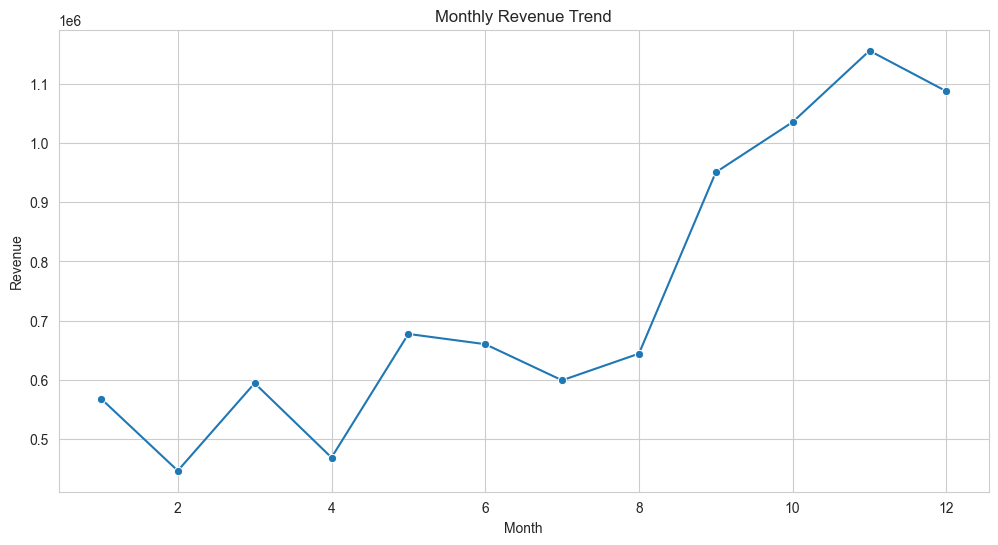

In [9]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

OBSERVATION:
- Revenue shows noticeable variation across different months.
- Sales increase significantly during the last quarter of the year.
- November and December appear to have peak sales, likely due to holiday shopping and seasonal demand.
- This indicates strong seasonality in customer purchasing behavior.

3. Top Countries by Revenue

In [10]:
top_countries = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

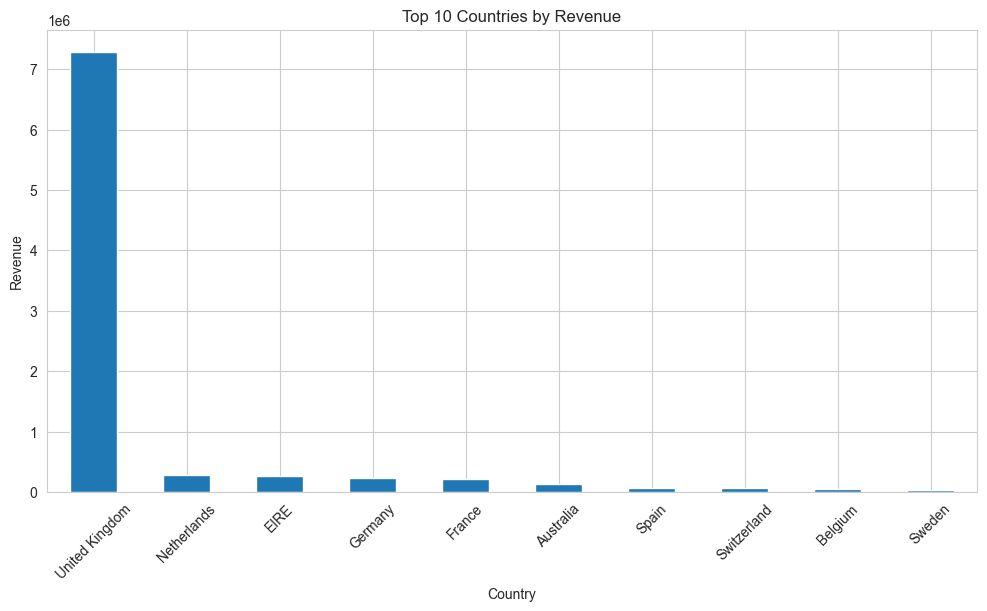

In [11]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

OBSERVATION:
- The United Kingdom contributes the highest share of total revenue.
- Other countries generate comparatively lower revenue volumes.
- The business appears heavily dependent on the UK market.
- This suggests potential opportunities for international market expansion.

4. Top Selling Products

In [12]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

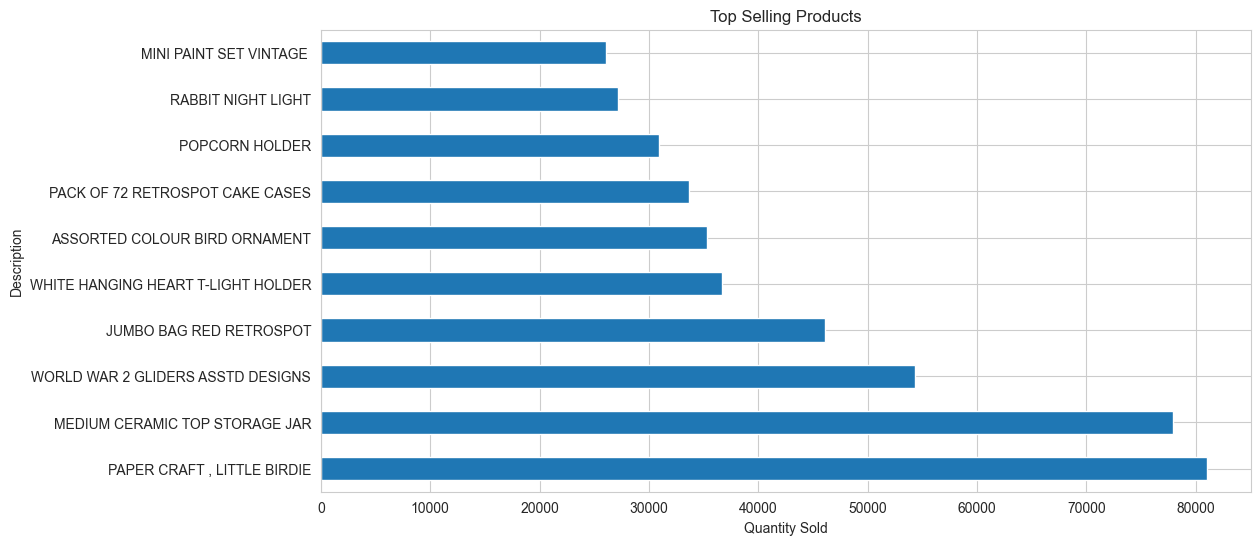

In [13]:
plt.figure(figsize=(12,6))

top_products.plot(kind='barh')

plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")

plt.show()

OBSERVATION:
- A small group of products contributes significantly to total sales volume.
- Certain decorative and household items dominate customer purchases.
- High-selling products can be prioritized for inventory planning and targeted promotions.
- Product demand concentration indicates the importance of bestseller management.

5. Sales Distribution

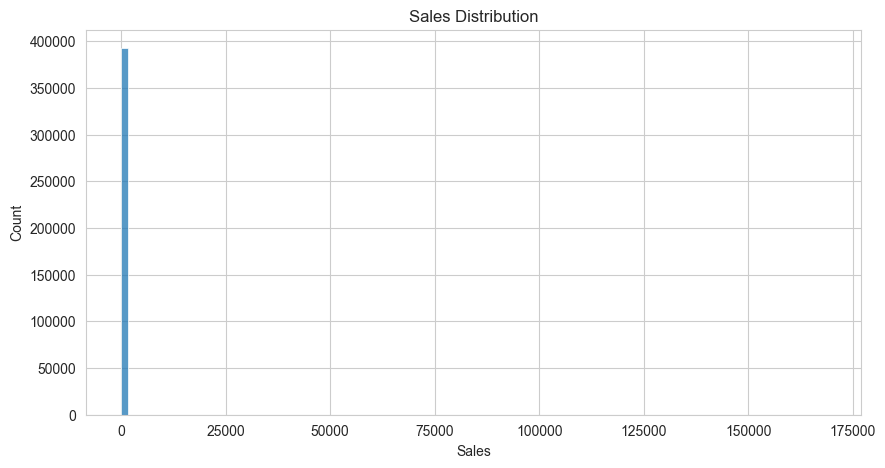

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Sales'],
    bins=100
)

plt.title("Sales Distribution")

plt.show()

OBSERVATION:
- The sales distribution is highly right-skewed.
- Most transactions involve low sales amounts, while a few transactions generate very high revenue.
- This pattern is common in retail and e-commerce datasets.
- Presence of large outliers suggests bulk purchases or high-value orders.

Log Transformation

Now apply:

x
′
=log(x+1)

In [15]:
df['LogSales'] = np.log1p(df['Sales'])

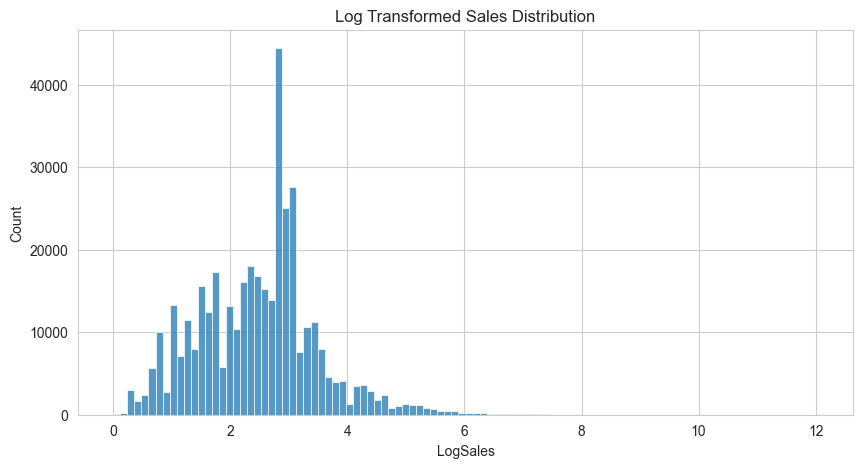

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['LogSales'],
    bins=100
)

plt.title("Log Transformed Sales Distribution")

plt.show()

OBSERVATION:
- Log transformation reduces the impact of extreme sales values.
- The transformed distribution appears more balanced and easier to analyze.
- This improves interpretability and can help machine learning models perform better.
- Data normalization techniques are useful for handling skewed business data.

6. Peak Shopping Hours

In [ ]:
# hourly_sales = (
#     df.groupby('Hour')['Sales']
#     .sum()
# )

# hourly_sales
hourly_orders = (
    df.groupby('Hour')['InvoiceNo']
    .nunique()
)

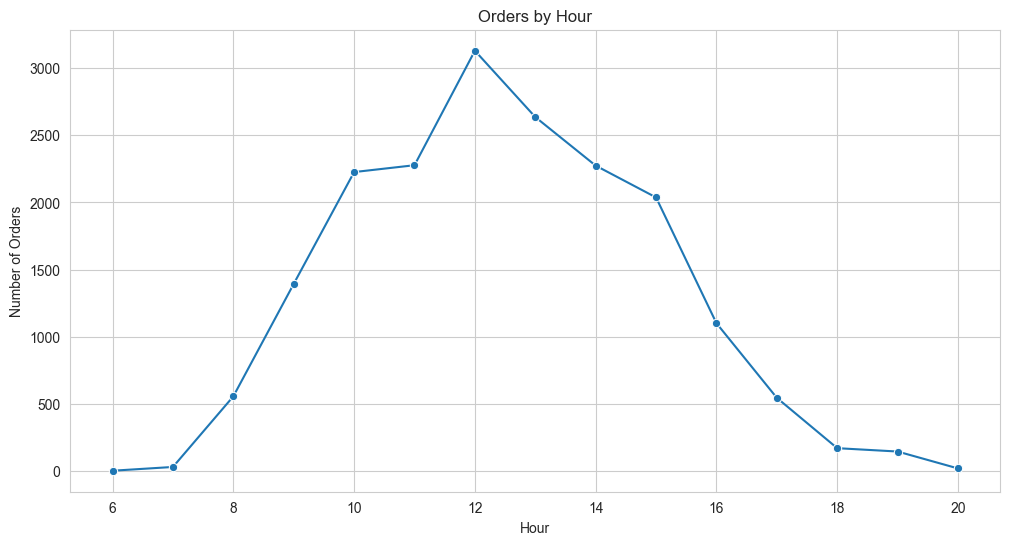

In [18]:
# plt.figure(figsize=(12,6))

# sns.lineplot(
#     x=hourly_sales.index,
#     y=hourly_sales.values,
#     marker='o'
# )

# plt.title("Revenue by Hour")
# plt.xlabel("Hour")
# plt.ylabel("Revenue")

# plt.show()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values,
    marker='o'
)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()

OBSERVATION:
- Orders are very low during early morning hours (6–7 AM).
- Order count increases steadily from 8 AM onwards.
- Peak orders are observed at 12 PM, making it the busiest hour
- Most customers prefer placing orders during late morning and lunchtime hours.

7. Weekday Analysis

In [19]:
weekday_sales = (
    df.groupby('Weekday')['Sales']
    .sum()
)

weekday_sales

Weekday
Friday       1483080.811
Monday       1363604.401
Sunday        785490.321
Thursday     1973015.730
Tuesday      1697733.801
Wednesday    1584283.830
Name: Sales, dtype: float64

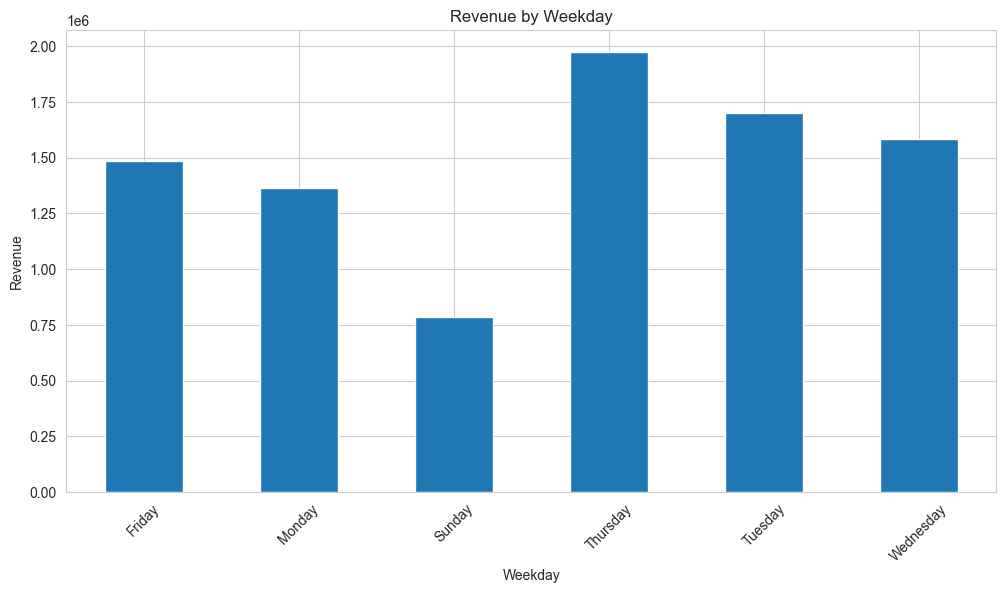

In [20]:
plt.figure(figsize=(12,6))

weekday_sales.plot(kind='bar')

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

OBSERVATION:
- Customer purchasing behavior differs across weekdays.
- Some weekdays generate noticeably higher revenue than others.
- Weekend and weekday performance differences may reflect customer shopping habits.
- This insight can support promotional scheduling and demand forecasting.

Customer Focused EDA

1. Top Customers Analysis

In [23]:
top_customers = (
    df.groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Sales, dtype: float64

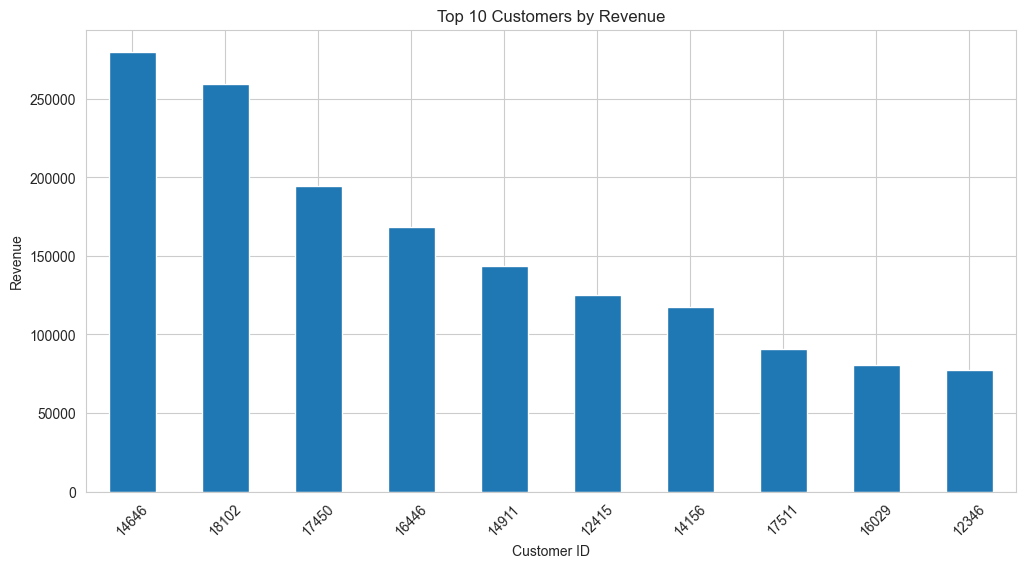

In [24]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Observation

- Customer 14646 recorded the highest sales with a revenue of 280,206.02.
- Customers 18102 and 17450 are also major contributors, generating more than 190K in sales.
- A significant revenue gap exists between the top customers and the lower-ranked customers in the top 10 list.
- The dataset indicates that a small number of customers contribute a large share of overall sales revenue.
- Even the lowest customer in the top 10 (12346) generated a strong sales value of 77,183.60, showing high customer purchasing power.

2. Average Monthly Revenue

In [25]:
monthly_avg_sales = (
    df.groupby('Month')['Sales']
    .mean()
)

monthly_avg_sales

Month
1     27.067911
2     22.637010
3     22.109481
4     20.878809
5     24.128349
6     24.513335
7     22.534345
8     24.040726
9     23.965570
10    21.225226
11    18.303660
12    25.473421
Name: Sales, dtype: float64

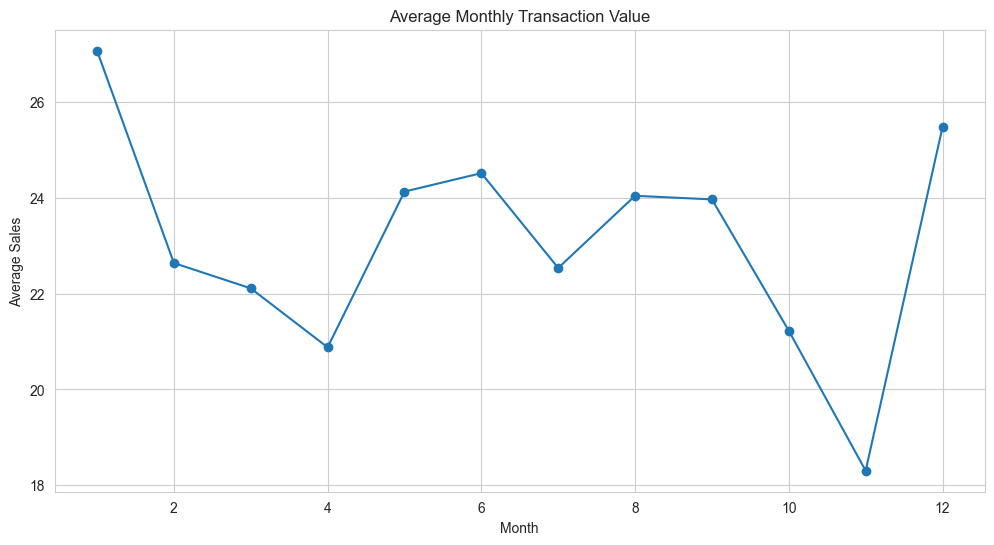

In [26]:
plt.figure(figsize=(12,6))

monthly_avg_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Average Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

Observation
- Month 1 (January) recorded the highest average sales value of 27.06, indicating strong customer spending during the beginning of the year.
- Month 12 (December) also showed high average sales at 25.47, possibly due to festive season and year-end shopping demand.
- Months 6, 8, and 9 maintained relatively stable sales performance with average sales around 24.
- Month 11 had the lowest average sales value of 18.30, showing a noticeable drop compared to other months.
- Overall, sales fluctuate moderately throughout the year, suggesting seasonal variations in customer purchasing behavior.

3. Correlation Analysis

In [29]:
correlation = df[
    ['Quantity', 'UnitPrice', 'Sales']
].corr()

correlation

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
Sales,0.914451,0.081619,1.000000


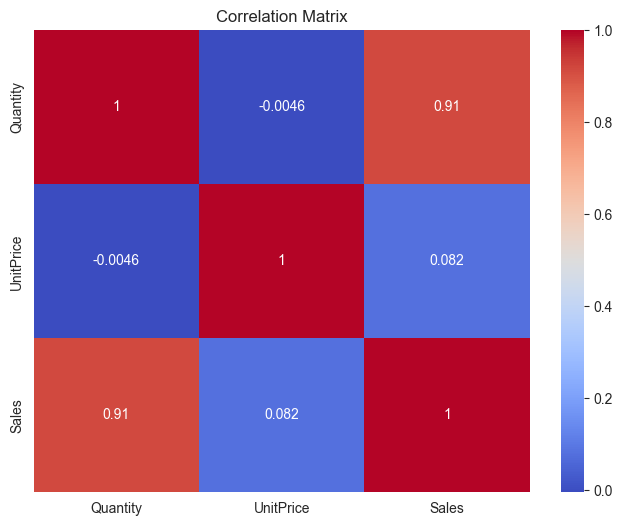

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Observation
- Quantity and Sales show a very strong positive correlation (0.91), which means higher product quantity sold directly increases total sales revenue.
- UnitPrice and Sales have a very weak positive correlation (0.08), indicating that sales are not strongly dependent on product price alone.
- Quantity and UnitPrice have a very small negative correlation (-0.004), which is almost equal to zero and indicates virtually no relationship between them.
- The negative value between Quantity and UnitPrice means that as product quantity increases, unit price tends to decrease slightly, possibly because cheaper products are purchased in larger quantities.
- Since the correlation value is extremely close to 0, the negative sign is not significant and can be treated as negligible in practical analysis.